In [15]:
from pathlib import Path
import pandas as pd
import sys
import numpy as np

ROOT = Path('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2')

df = pd.read_csv(ROOT / 'exploration' / 'data' / 'master_data' / '2016_to_2023_clustering_output_data.csv')
print(df.columns.tolist())
print(df.shape)

sys.path.append(str(ROOT / 'src' / 'stream_1' / 'forecasting'))
from forecasting_class import Forecast

['serial', 'year', 'month', 'calendar_year', 'calendar_month', 'wt_final', 'LCA_Class', 'LA_2023', 'active', 'Age9', 'Gend3', 'Eth7', 'Disab2_POP', 'Educ6', 'NSSEC5', 'IMD10', 'WorkStat8', 'Child4', 'HHLiv9', 'Motiva_POP', 'motivd_POP', 'nadult', 'nchild', 'health', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'DVBMI', 'FruitVegPor', 'READYAB1_POP', 'CULFRQ_1_9_POP', 'VolAny', 'VolCnt', 'VolDur', 'VolFrqB_Pop', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7', 'MEMS7_ALL', 'MEMS7_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_FITNESS_B06', 'MEMS7_WALKALL_C01', 'MEMS7_CYCALL_C02', 'MEMS7_ACTTRAV_C03', 'MEMS7_DANCEALL_C04', 'MEMS7_TEAMSPORT_C05', 'MEMS7_RACKETSPORT_C06', 'MEMS7_ADVWATERSPORT_C07', 'MEMS7_LEISURE_C08', 'MEMS7_COMBATTARGET_C09', 'MEMS7_WINTER_C10', 'MEMS7_RUNATHMULTI_C11', 'ACT7GR_ALL', 'ACT7GR_SPORTCOUNT_A01', 'Number_Activities', 'CLUB_SPORTCOUNT_A01', 'Number_Club']
(85659, 65)


In [16]:
df = pd.read_csv(ROOT / 'exploration' / 'data' / 'master_data' / '2016_to_2023_clustering_output_data.csv')

# quarterly
df_lca_quarterly = df[df['LCA_Class'].notna()].copy()
df_lca_quarterly['year'] = df_lca_quarterly['year'].str.split('/').str[1].astype(int) + 2000
df_lca_quarterly['month'] = ((df_lca_quarterly['month'].astype(int) - 3) % 12) + 1
df_lca_quarterly['quarter'] = pd.cut(df_lca_quarterly['month'], bins=[0,3,6,9,12], labels=[1,2,3,4])
df_lca_quarterly = df_lca_quarterly.groupby(['LCA_Class', 'year', 'quarter']).agg(MEMS7_ALL=('MEMS7_ALL', 'mean')).reset_index()

# monthly
df_lca_monthly = df[df['LCA_Class'].notna()].copy()
df_lca_monthly['year'] = df_lca_monthly['year'].str.split('/').str[1].astype(int) + 2000
df_lca_monthly['month'] = ((df_lca_monthly['month'].astype(int) - 3) % 12) + 1
df_lca_monthly.loc[df_lca_monthly['month'].isin([11,12]), 'year'] = df_lca_monthly['year'] - 1
df_lca_monthly = df_lca_monthly.groupby(['LCA_Class', 'year', 'month']).agg(MEMS7_ALL=('MEMS7_ALL', 'mean')).reset_index()

In [17]:
from forecasting_class import Forecast
print("quarter")
sqc = Forecast(df_lca_quarterly, forecast_steps=20, group_col='LCA_Class')
sqc.sarima()
print(sqc.get_mae('sarima'))

print("month")
smc = Forecast(df_lca_monthly, forecast_steps=60, group_col='LCA_Class')
smc.sarima()
print(smc.get_mae('sarima'))

quarter
22.926512682572188
month
32.81203760971434


---------------------------
----- YEARLY FORECAST -----
---------------------------
18.213282341337067


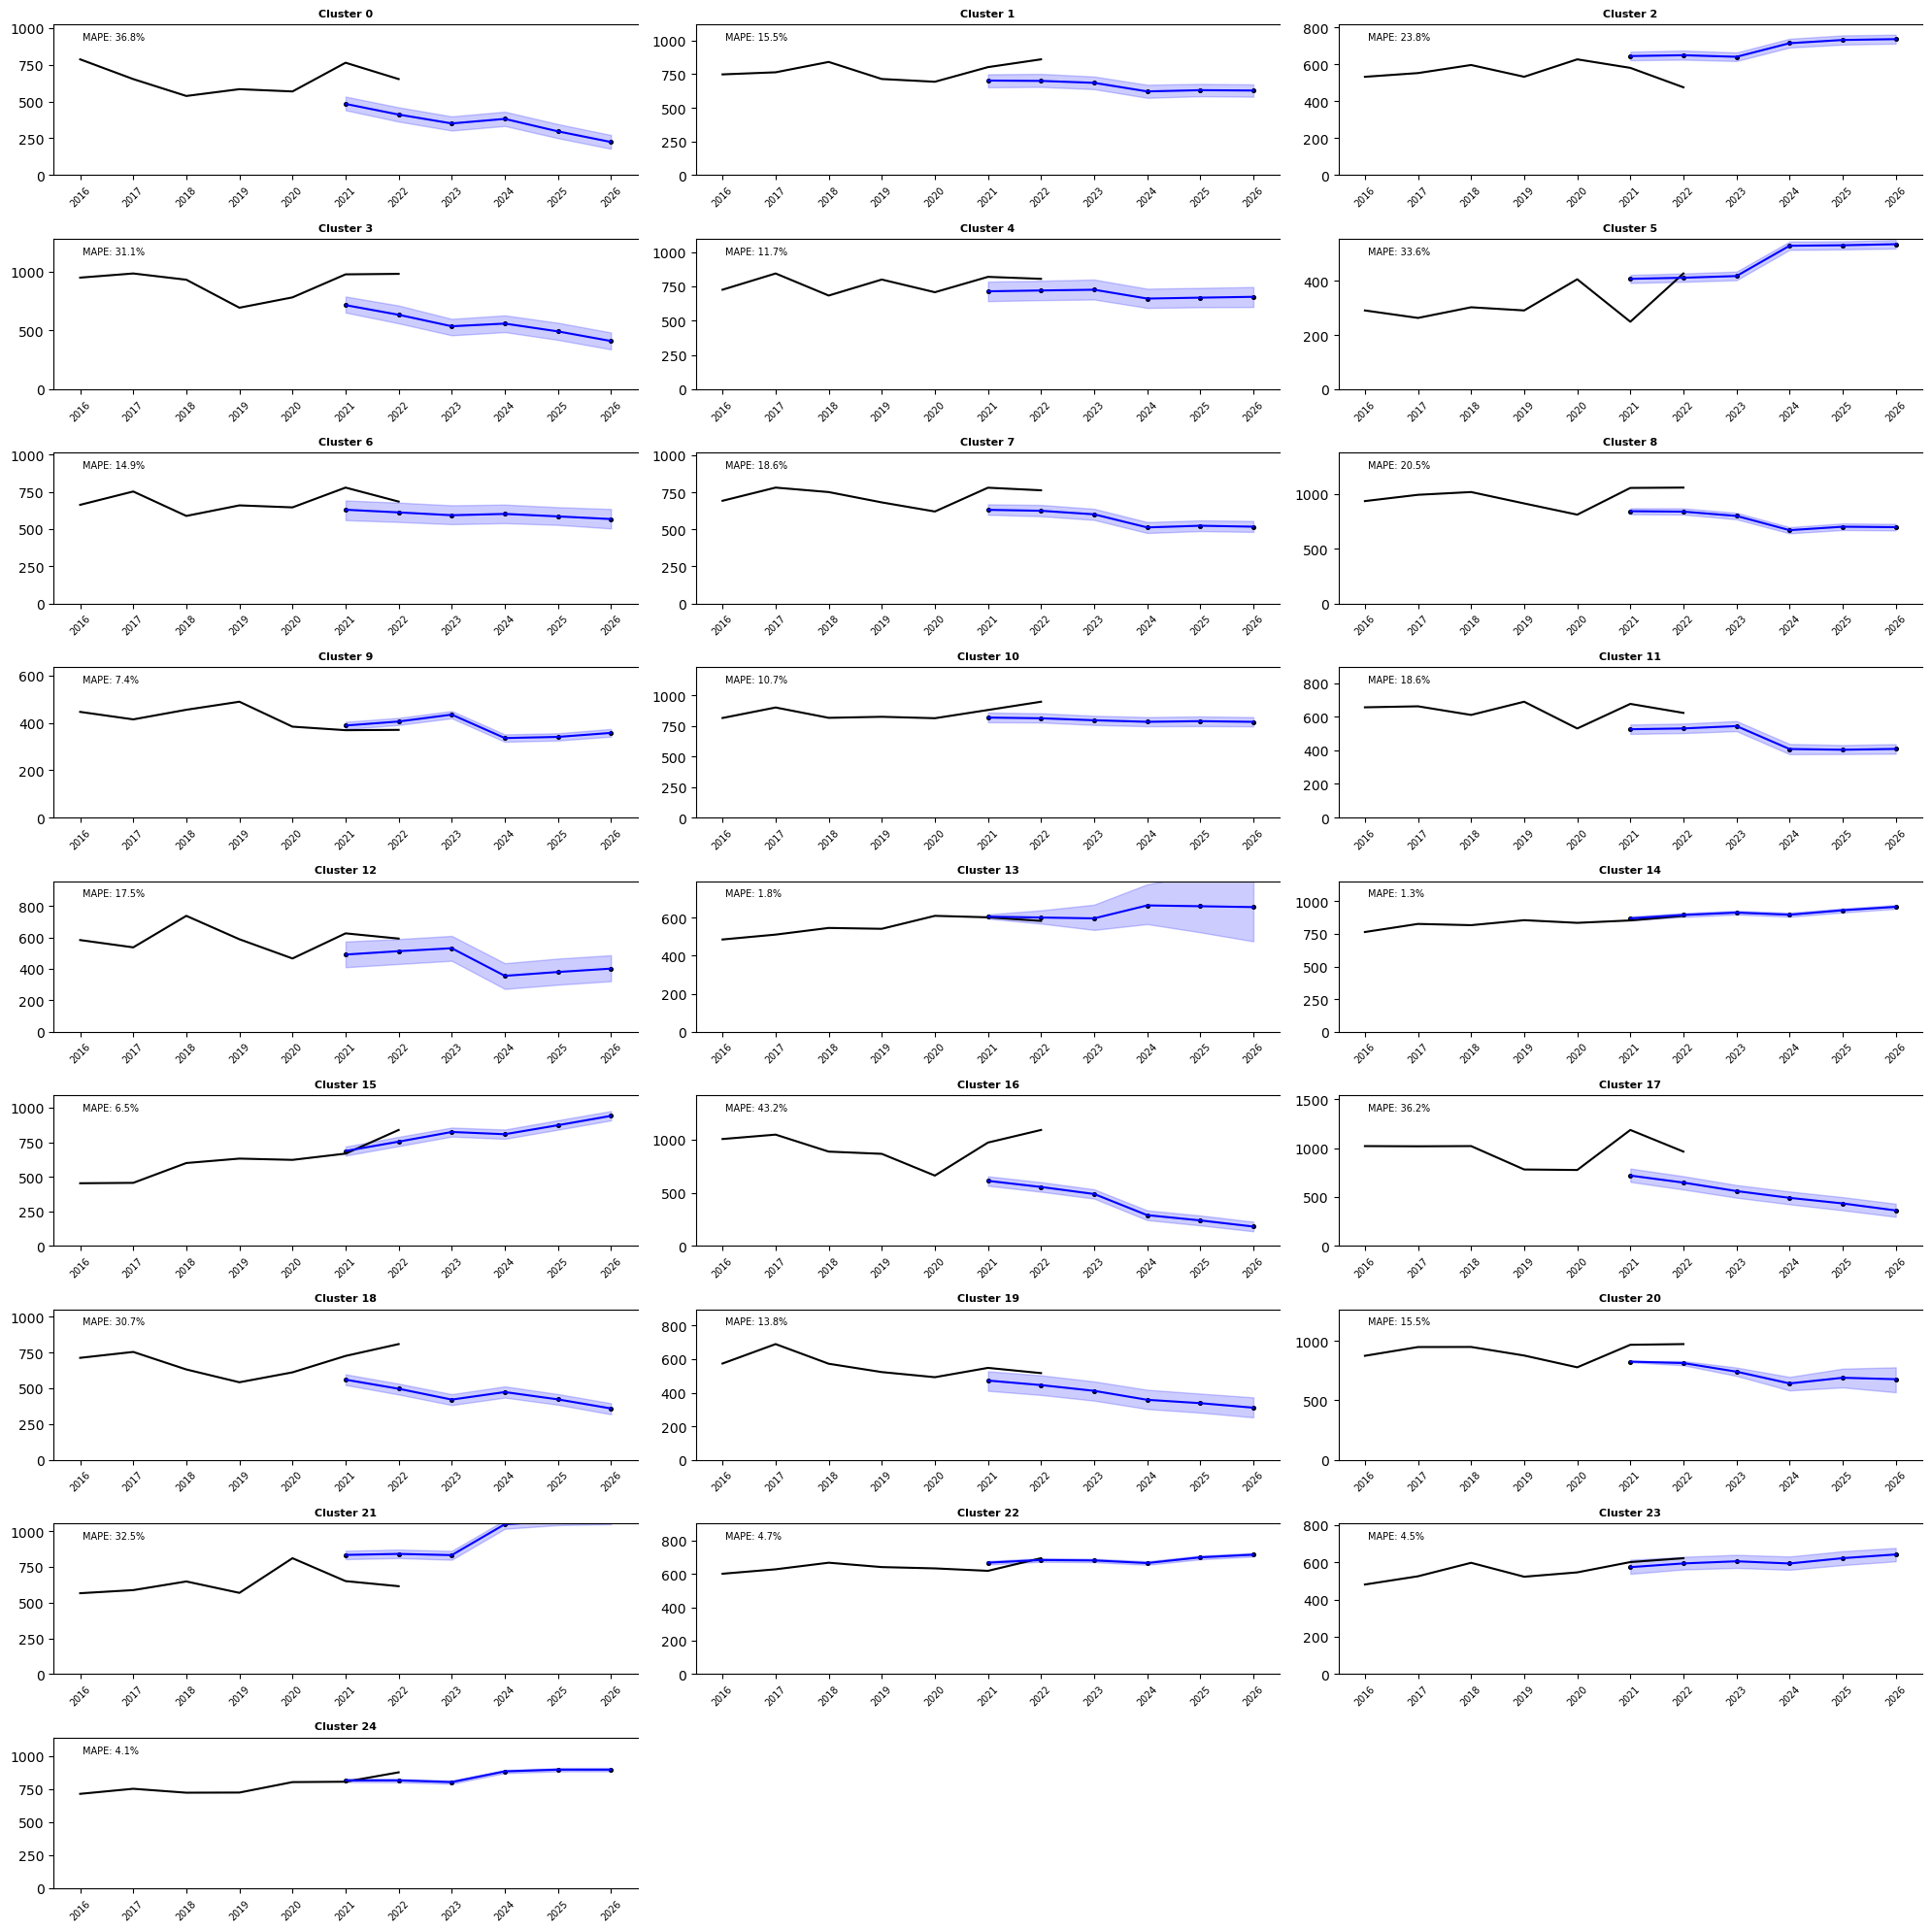

In [ ]:
print("---------------------------")
print("----- YEARLY FORECAST -----")
print("---------------------------")
print(np.mean(results_lca['mape']))
xtick_positions = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
xtick_labels = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
plot_cluster_forecasts(results_lca, t_train_cutoff=5, xtick_positions=xtick_positions, xtick_labels=xtick_labels, group_col='LCA_Class', UNCERTAINTY=True)

------------------------------
----- QUARTERLY FORECAST -----
------------------------------
24.792553314979806


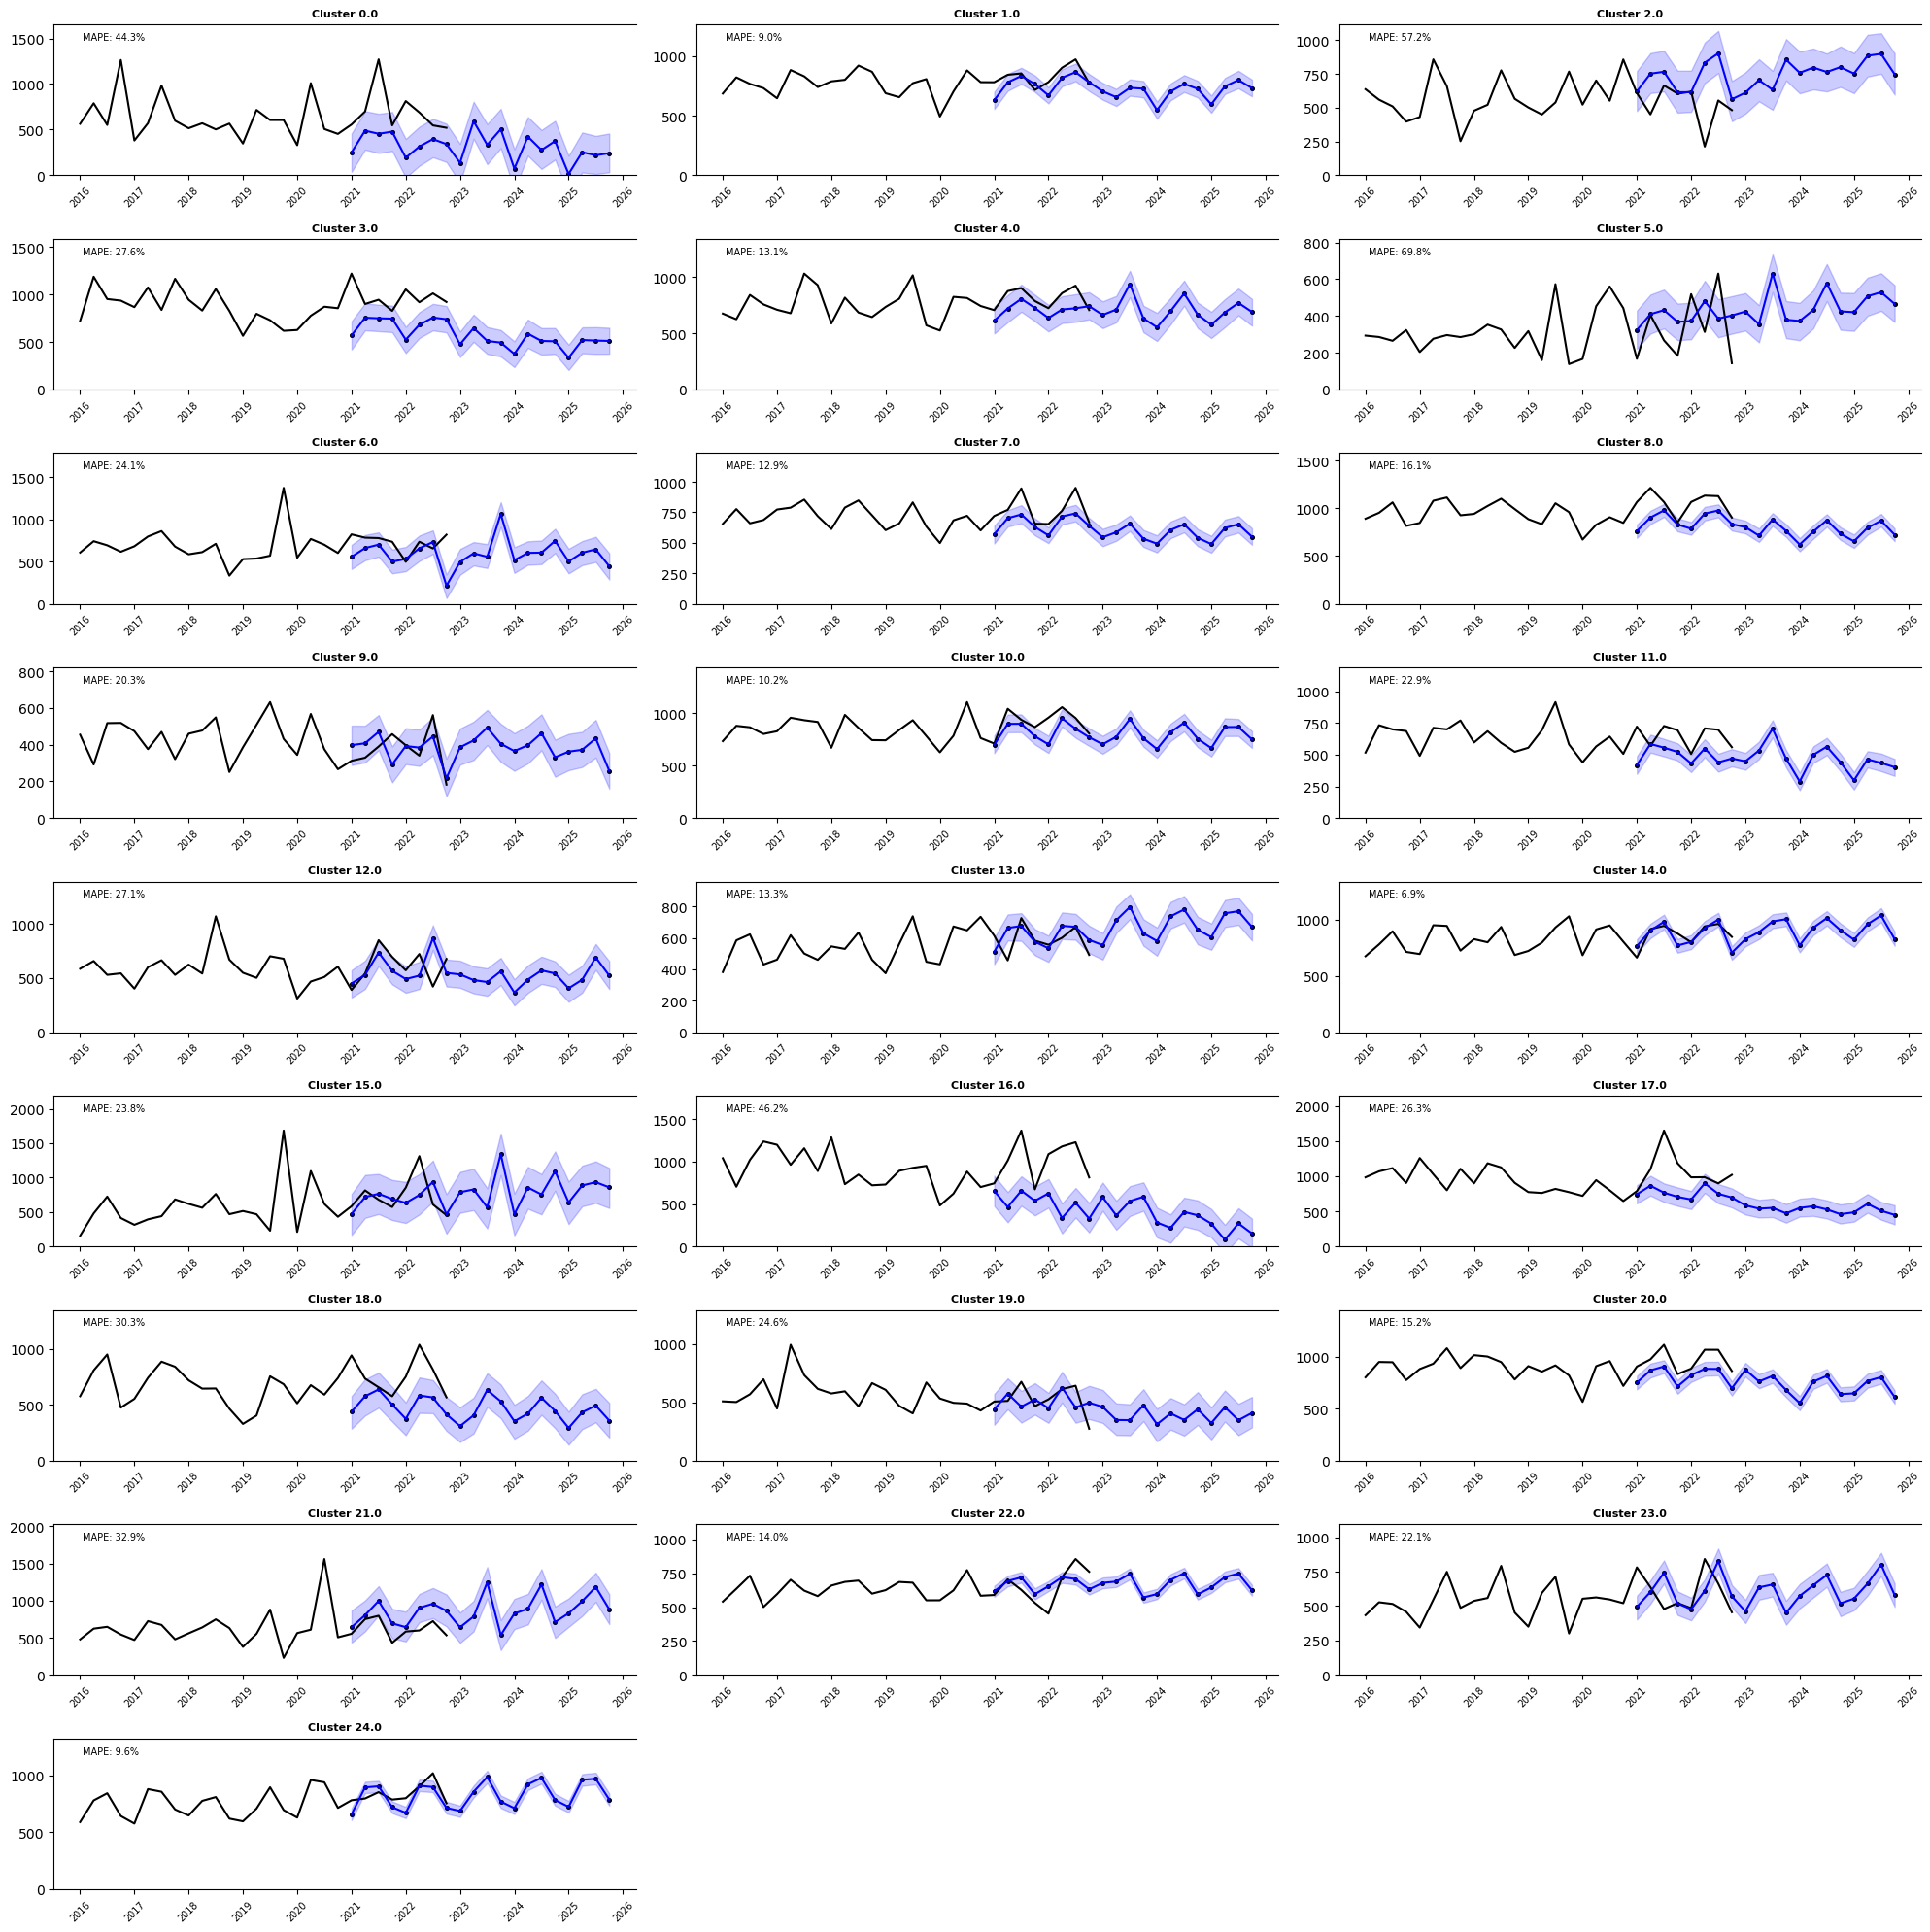

In [ ]:
print("------------------------------")
print("----- QUARTERLY FORECAST -----")
print("------------------------------")
print(np.mean(results_lca_q['mape']))
xtick_positions = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]
xtick_labels = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
plot_cluster_forecasts(results_lca_q, t_train_cutoff=20, xtick_positions=xtick_positions, xtick_labels=xtick_labels, group_col='LCA_Class', UNCERTAINTY=True)

-------------------------------------
----- QUARTERLY SARIMA FORECAST -----
-------------------------------------
23.230478133587216


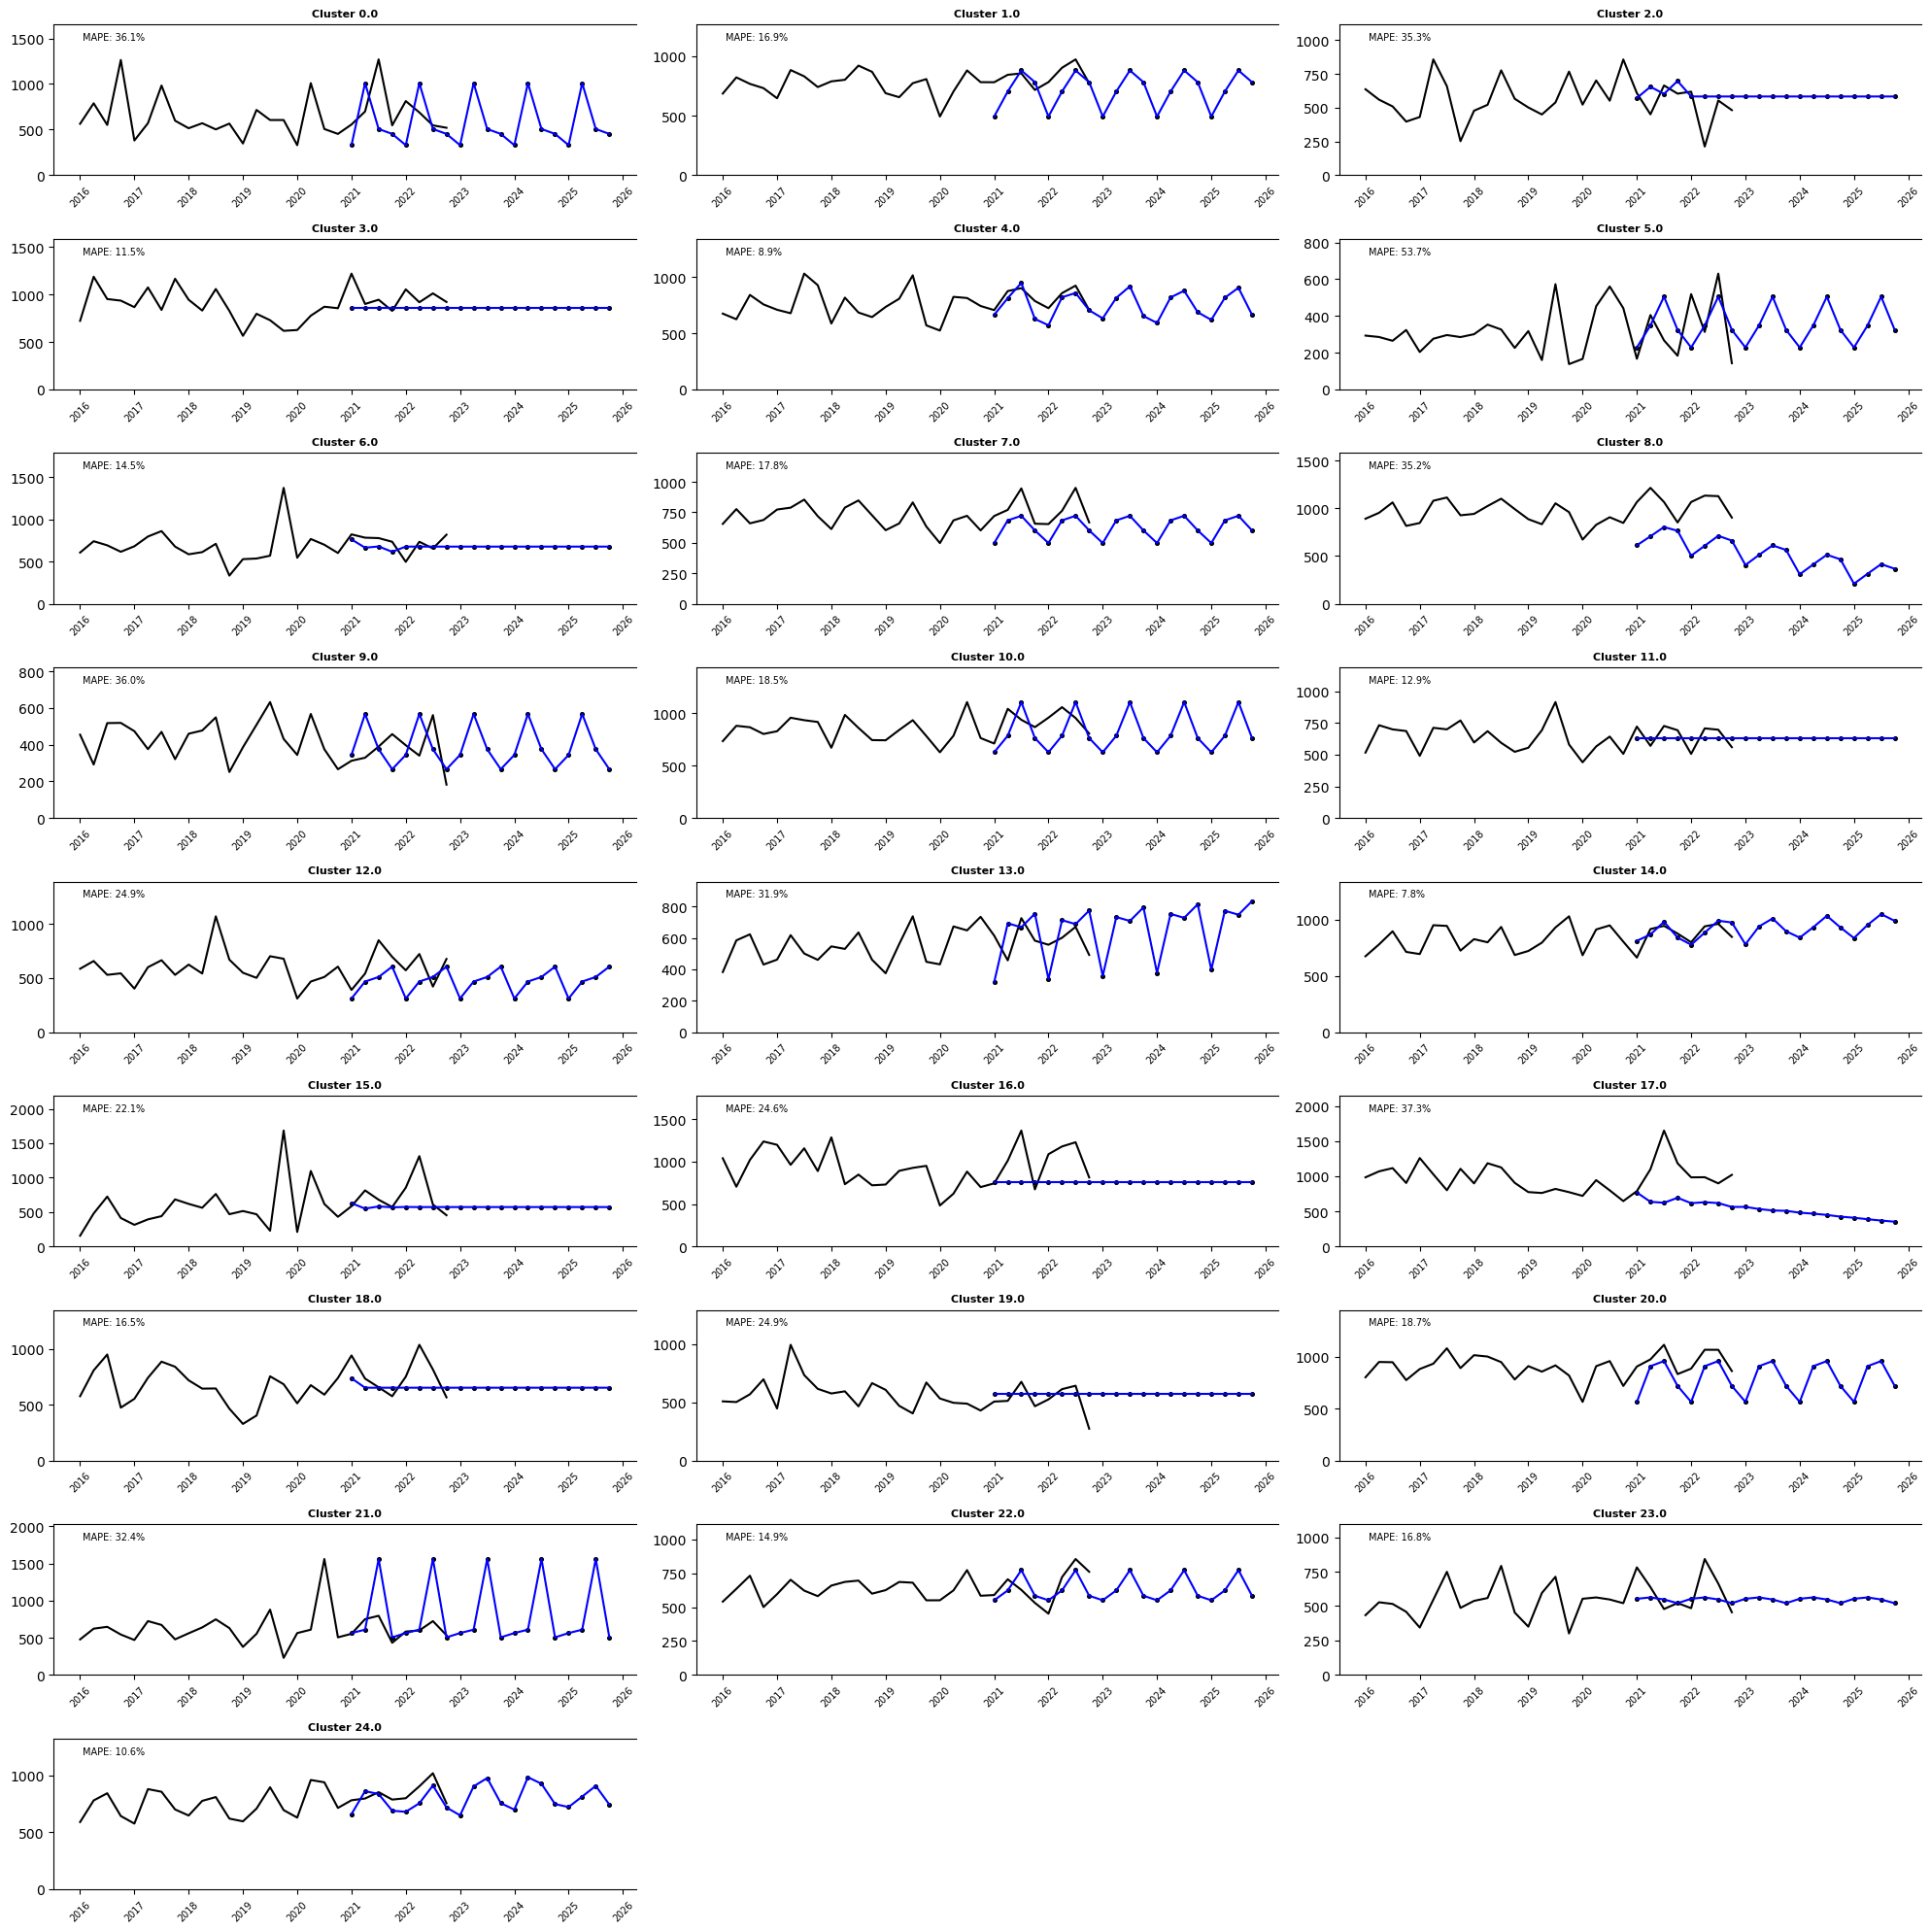

In [ ]:
print("-------------------------------------")
print("----- QUARTERLY SARIMA FORECAST -----")
print("-------------------------------------")
print(np.mean(results_sarima['mape']))
xtick_positions = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]
xtick_labels = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
plot_cluster_forecasts(results_sarima, t_train_cutoff=20, xtick_positions=xtick_positions, xtick_labels=xtick_labels, group_col='LCA_Class')